In [1]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel
import torch
from torch import nn
from sklearn.manifold import TSNE
import random
from mpl_toolkits.mplot3d import Axes3D

In [3]:
class DecoderAdapter(nn.Module):
    def __init__(self, embedding_size, prompt_size=512):
        super().__init__()
        self.embedding_size = embedding_size
        self.prompt_size = prompt_size

        # 
        self.prompt = nn.Parameter(torch.randn(prompt_size, embedding_size))  

        self.linear_q = nn.Linear(embedding_size, embedding_size)
        self.linear_k = nn.Linear(embedding_size, embedding_size)
        self.linear_v = nn.Linear(embedding_size, embedding_size)

        self.linear_o = nn.Linear(embedding_size, embedding_size)
        self.linear_t = nn.Linear(embedding_size, embedding_size)

        self.softmax = nn.Softmax(dim=-1)
        self.g_l = nn.Parameter(torch.tensor(0.0))

    def forward(self, T_l):
        
        Q_l = self.linear_q(T_l)              
        K_l = self.linear_k(self.prompt)      
        V_l = self.linear_v(self.prompt)     

        attn_scores = torch.matmul(Q_l, K_l.transpose(0, 1)) / (self.embedding_size ** 0.5)  
        attn_weights = self.softmax(attn_scores)                                    

        S_l = torch.matmul(attn_weights, V_l)    
        S_l = self.linear_o(S_l)                 

        T_l = self.linear_t(T_l + self.g_l * S_l)  

        return T_l

In [4]:
embedding_size = 64
prompt_size = 512
adapter = DecoderAdapter(embedding_size, prompt_size)

# Dummy input tensor T_l of shape [M, embedding_size], e.g., M=10
M = 10
T_l = torch.randn(M, embedding_size)

# Forward pass
output = adapter(T_l)

print("Input shape:", T_l.shape)
print("Output shape:", output.shape)
print("Output tensor:", output)



Input shape: torch.Size([10, 64])
Output shape: torch.Size([10, 64])
Output tensor: tensor([[ 0.6131,  0.9994, -0.4572, -0.3482,  0.1831, -0.4365, -0.7319,  0.0041,
          0.3224,  0.3268,  0.6976,  0.2493, -0.4700, -0.4465, -0.1556,  0.7851,
         -0.4675,  0.0369,  0.2643, -0.1677,  0.8424,  0.9992, -0.2207, -1.1347,
          0.5694, -0.0746, -0.0838,  0.4418,  0.0227, -0.3072, -0.1058, -0.9210,
         -0.5409,  0.2117, -0.5449,  0.4300, -0.5383,  0.0501,  0.7287,  0.4089,
          0.3234,  0.5935,  0.0530,  0.0580,  0.2659,  0.0129,  0.1239, -0.0218,
         -0.9355,  0.2974, -0.6574, -0.3936,  0.3066, -0.0960,  0.1388, -0.2529,
         -0.5582,  0.6000,  0.3642,  0.2971,  0.3113, -0.1298,  0.1036,  0.6141],
        [-0.4216, -0.4195,  0.8989,  1.1886,  0.0224, -0.2105,  0.6924,  0.3423,
          0.1909, -0.0288,  0.0471, -1.0540, -0.3442, -0.1308,  0.4133, -0.1415,
         -0.4778, -0.3651,  0.6794, -0.5069,  0.2160, -0.8436, -0.4803,  0.7267,
          0.5173,  0.068

In [5]:
random.seed(50301)

In [26]:
def load_data_npy(folder_path):
    data = []
    

    files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    sample_files = random.sample(files, k=10) 

    for filename in sample_files:
        if filename.endswith('.npy'):
            filepath = os.path.join(folder_path, filename)
            sample = np.load(filepath)[60:120]
            sample = sample.reshape(160, -1).mean(axis=0)
            data.append(sample)

    data = np.stack(data) 
    return data

## Load Data

In [27]:
SSA_path_box = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_SSA/MedSAM2/boxes_con'
GLI_path_box = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_GLI/MedSAM2/boxes_con'
BGLI_path_box = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_SSA/MedSAM2/boxes_con'

In [28]:
SSA_path_un = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_SSA/MedSAM2/boxes_uncon'
GLI_path_un = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_GLI/MedSAM2/boxes_uncon'
BGLI_path_un = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_med/BraTS_SSA/MedSAM2/boxes_uncon'

In [29]:
SSA_un = load_data_npy(SSA_path_un)
# GLI_np = load_data_npy(GLI_path_box)
BGLI_un = load_data_npy(BGLI_path_un)

In [30]:
SSA_np = load_data_npy(SSA_path_box)
# GLI_np = load_data_npy(GLI_path_box)
BGLI_np = load_data_npy(BGLI_path_box)

In [31]:
features = np.concatenate([SSA_np,BGLI_np])
features.shape

(20, 98304)

In [32]:
features_un = np.concatenate([SSA_un,BGLI_un])
features_un.shape

(20, 589824)

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)  # or choose to preserve 95% variance
features_pca = pca.fit_transform(features)

In [35]:
pca1 = PCA(n_components=5)  # or choose to preserve 95% variance
features_un = pca1.fit_transform(features_un)

## Plot Conditioned

In [39]:
zeroes = np.zeros(10)
ones = np.ones(10)
labels = np.concatenate([zeroes,ones])

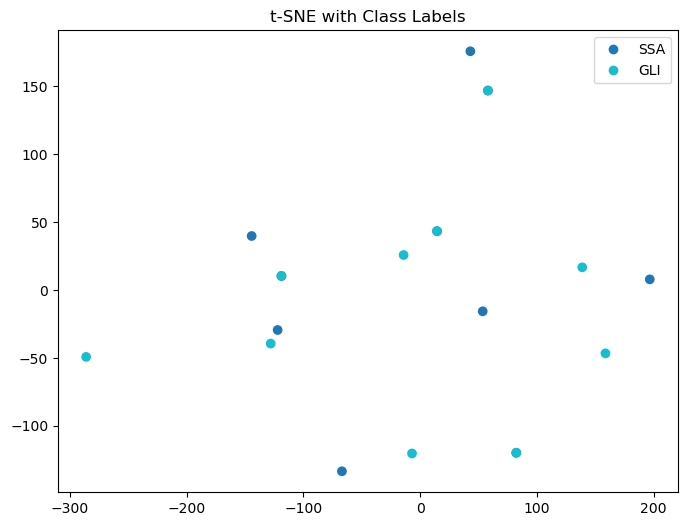

In [40]:
tsne = TSNE(n_components=3, perplexity=2, random_state=42)
embedded = tsne.fit_transform(features_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap='tab10')
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

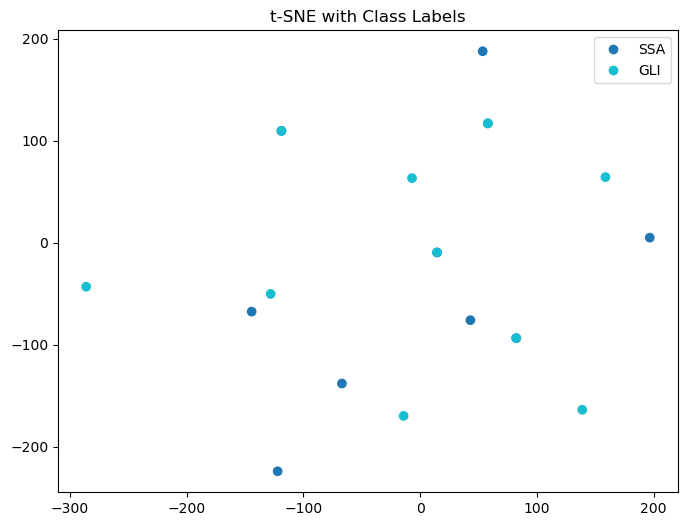

In [41]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded[:, 0], embedded[:, 2], c=labels, cmap='tab10')
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

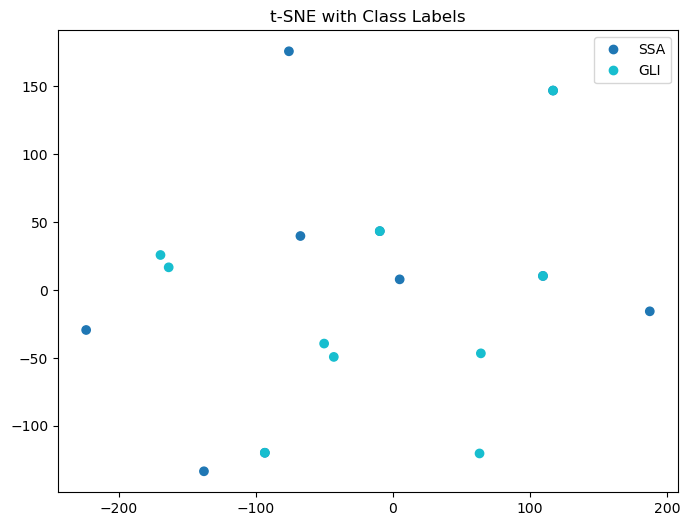

In [43]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded[:, 2], embedded[:, 1], c=labels, cmap='tab10')
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

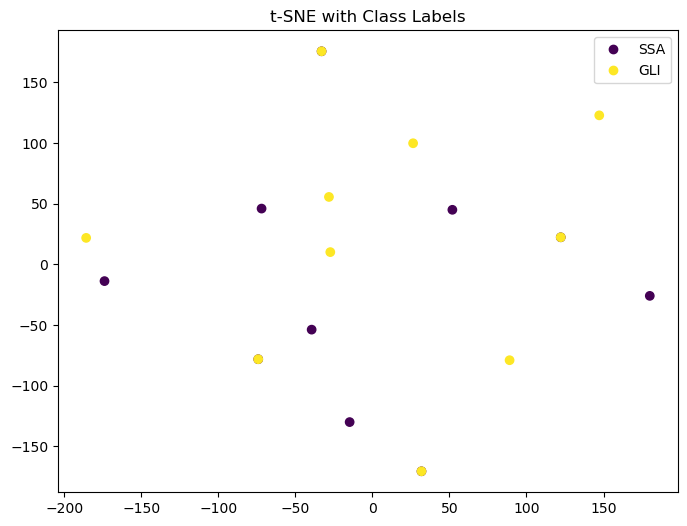

In [44]:
tsne1 = TSNE(n_components=3, perplexity=30, random_state=42)
embedded1 = tsne.fit_transform(features_un)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded1[:, 0], embedded1[:, 1], c=labels)
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

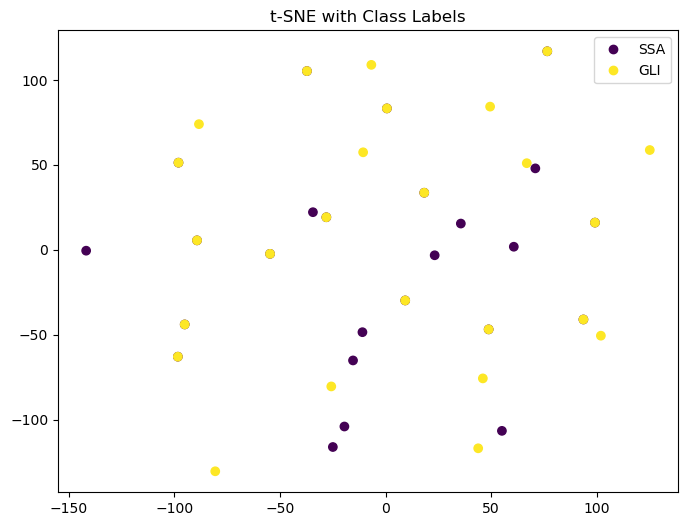

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded1[:, 2], embedded1[:, 1], c=labels)
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

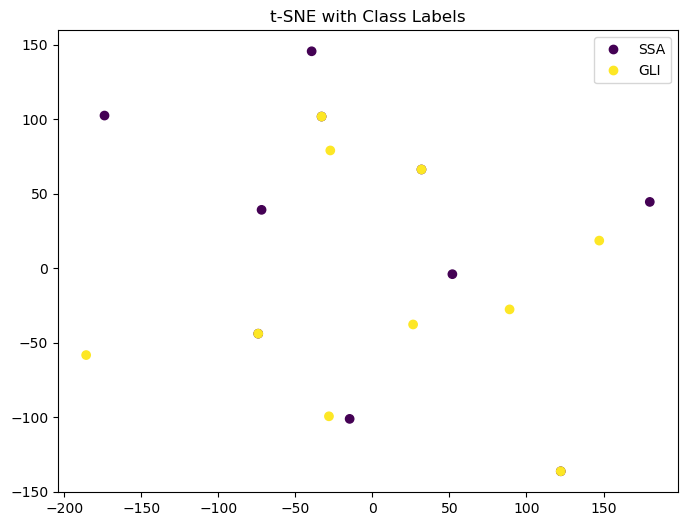

In [45]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedded1[:, 0], embedded1[:, 2], c=labels)
plt.title("t-SNE with Class Labels")
plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
plt.show()

In [ ]:
# plt.figure(figsize=(8, 6))
# scatter = plt.scatter(embedded1[:, 0], embedded1[:, 1], c=labels)
# plt.scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap='tab10')
# plt.title("t-SNE with Class Labels")
# plt.legend(handles=scatter.legend_elements()[0], labels=['SSA', 'GLI'])
# plt.show()

In [46]:
from scipy.stats import wasserstein_distance

# x and y are 1D arrays (e.g., features projected onto one dimension)
x = [0.0, 1.0, 2.0]
y = [0.0, 1.5, 3.0]

emd = wasserstein_distance(x, y)
print("EMD (Wasserstein-1) distance:", emd)

EMD (Wasserstein-1) distance: 0.5


In [47]:
import torch

def gaussian_kernel(x, y, sigma=1.0):
    xx = x.unsqueeze(1)  # [batch_size_x, 1, features]
    yy = y.unsqueeze(0)  # [1, batch_size_y, features]
    dist = ((xx - yy) ** 2).sum(2)  # [batch_size_x, batch_size_y]
    return torch.exp(-dist / (2 * sigma ** 2))

def compute_mmd(x, y, sigma=1.0):
    Kxx = gaussian_kernel(x, x, sigma)
    Kyy = gaussian_kernel(y, y, sigma)
    Kxy = gaussian_kernel(x, y, sigma)
    mmd_value = Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()
    return mmd_value.item()  # returns a scalar float



In [48]:
import torch

features_A = torch.tensor(features_un[0:12], dtype=torch.float32)
features_B = torch.tensor(features_un[12:], dtype=torch.float32)

distance = compute_mmd(features_A, features_B)
print("MMD distance between feature sets:", distance)

MMD distance between feature sets: 0.12660834193229675


In [49]:
features_A = torch.tensor(features_pca[0:12], dtype=torch.float32)
features_B = torch.tensor(features_pca[12:], dtype=torch.float32)

distance = compute_mmd(features_A, features_B)
print("MMD distance between feature sets:", distance)

MMD distance between feature sets: 0.1319444477558136
